# Calcular rezagos

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_procesados = pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\datos_procesados\datos_procesados_originales\datos_procesados_sin_var_orig.xlsx")
# hacer que fecha sea el indice y sea de tipo datetime
df_procesados['fecha'] = pd.to_datetime(df_procesados['fecha']) # convertir en tipo datetime
df_procesados.set_index('fecha', inplace=True)  # hacer que fecha sea el indice 
df_procesados.head()

,año,semana_epi,casos_ln,prec_ln,dias_lluvia_ln,temp_bc,temp_max_bc,temp_min_bc,hum_esp_bc,hum_rel_bc,vel_vi_bc,vel_vi_max_bc,vel_vi_min_bc,uv_bc,soi_yj,sst_yj
fecha,,,,,,,,,,,,,,,,
2021-01-03,2021,1,-2.254057,-0.716557,-1.287582,0.777755,1.147942,-0.698761,-1.459162,-1.286497,-1.110633,-0.752514,0.970687,0.284735,1.432593,-1.726035
2021-01-10,2021,2,-2.254057,-0.008387,0.420558,0.979193,1.292774,-0.252083,-0.986872,-1.155330,-1.864950,-1.741631,0.390308,0.424653,1.251647,-1.721237
2021-01-17,2021,3,-1.667348,-2.051022,-2.365299,1.375442,1.535146,-0.381025,-1.566311,-1.524280,-1.190152,-1.369313,0.878558,1.147566,0.545162,-1.403882
2021-01-24,2021,4,-2.254057,-0.328950,0.420558,1.238552,1.476318,-0.246876,-1.368638,-1.409824,-1.190152,-1.482924,0.180094,1.391362,0.983127,-1.181283
2021-01-31,2021,5,-2.254057,-0.056645,-0.209866,1.324791,1.461364,0.331489,-0.990763,-1.335959,-1.518601,-1.391847,-0.272288,0.582532,0.403642,-1.323334


# Correlación simple

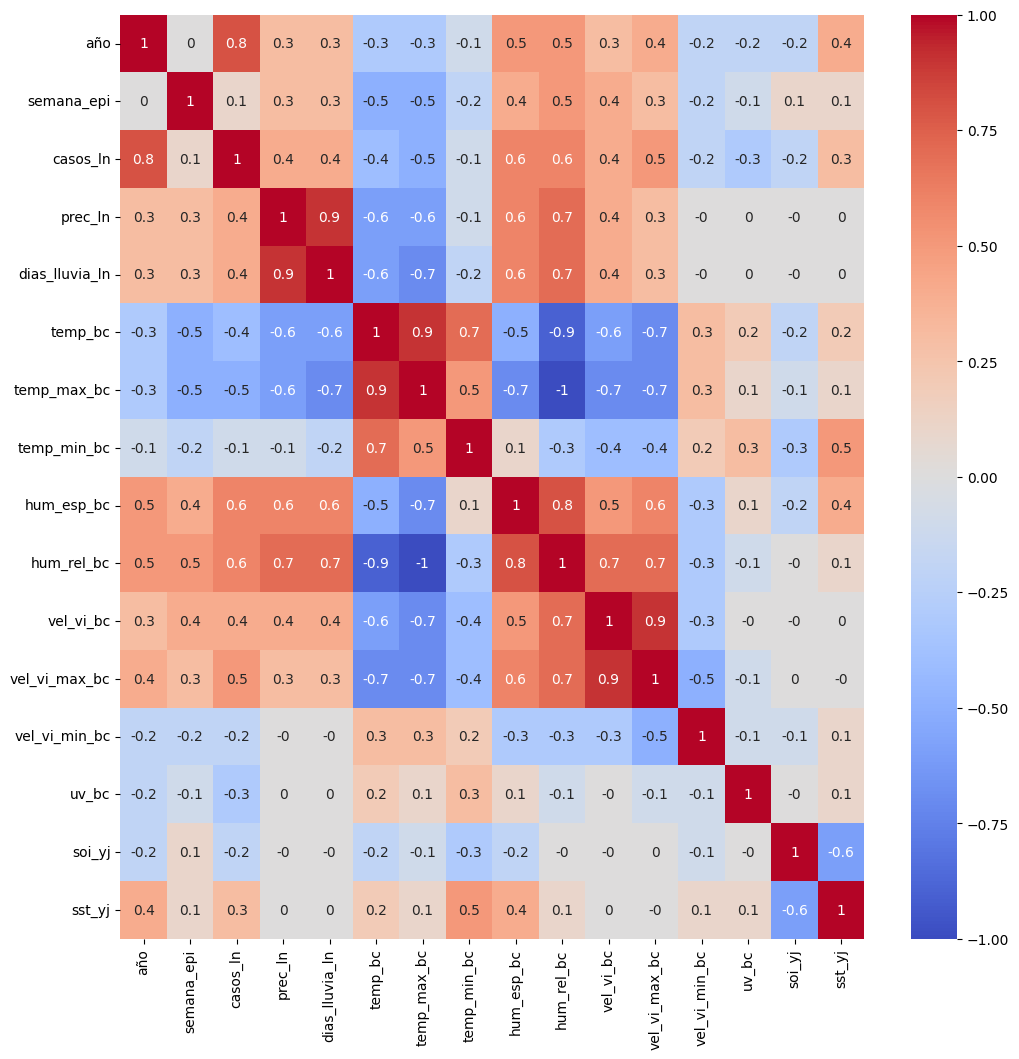

In [3]:
import seaborn as sns

plt.figure(figsize=(12,12))
sns.heatmap(df_procesados.corr(method='pearson').round(1), annot=True, cmap="coolwarm")
#plt.savefig(f"{ubicacion_imagenes_janis}/9.heatmap_correlacion.png")
plt.show()

# Correlación spearman

In [4]:
df_corr = df_procesados.select_dtypes(include=['float64', 'int64']).drop(columns=['año'])

In [5]:
# Seleccionar solo variables numéricas (sin fecha)
df_corr = df_procesados.select_dtypes(include=['float64', 'int64'])

# Eliminar año y semana_epi
df_corr = df_corr.drop(columns=['año', 'semana_epi'])

# Calcular correlación de Spearman
corr_spearman = df_corr.corr(method='spearman')

# Mostrar
print("Matriz de correlación de Spearman:\n")
corr_spearman

Matriz de correlación de Spearman:



,casos_ln,prec_ln,dias_lluvia_ln,temp_bc,temp_max_bc,temp_min_bc,hum_esp_bc,hum_rel_bc,vel_vi_bc,vel_vi_max_bc,vel_vi_min_bc,uv_bc,soi_yj,sst_yj
casos_ln,1.000000,0.317112,0.348841,-0.287819,-0.339709,-0.046010,0.564113,0.464611,0.330541,0.391557,-0.196582,-0.213838,-0.196389,0.397949
prec_ln,0.317112,1.000000,0.810945,-0.551170,-0.641219,-0.175068,0.589655,0.706660,0.355337,0.314923,-0.058065,0.089970,0.005448,0.029894
dias_lluvia_ln,0.348841,0.810945,1.000000,-0.610387,-0.689701,-0.235982,0.578096,0.741996,0.389673,0.349687,-0.060783,0.080115,-0.007930,0.022511
temp_bc,-0.287819,-0.551170,-0.610387,1.000000,0.944786,0.709083,-0.427293,-0.829621,-0.639075,-0.637787,0.262141,0.204664,-0.175209,0.248542
temp_max_bc,-0.339709,-0.641219,-0.689701,0.944786,1.000000,0.497945,-0.602966,-0.933549,-0.654996,-0.641868,0.259330,0.098308,-0.070535,0.074861
temp_min_bc,-0.046010,-0.175068,-0.235982,0.709083,0.497945,1.000000,0.158731,-0.329665,-0.328023,-0.359118,0.144778,0.348215,-0.338546,0.579728
hum_esp_bc,0.564113,0.589655,0.578096,-0.427293,-0.602966,0.158731,1.000000,0.771267,0.539510,0.580681,-0.341024,0.110660,-0.232610,0.391505
hum_rel_bc,0.464611,0.706660,0.741996,-0.829621,-0.933549,-0.329665,0.771267,1.000000,0.628244,0.631533,-0.311171,-0.041107,-0.002524,0.067323
vel_vi_bc,0.330541,0.355337,0.389673,-0.639075,-0.654996,-0.328023,0.539510,0.628244,1.000000,0.896362,-0.281090,-0.027398,-0.032116,0.029534
vel_vi_max_bc,0.391557,0.314923,0.349687,-0.637787,-0.641868,-0.359118,0.580681,0.631533,0.896362,1.000000,-0.490157,-0.066853,-0.011303,-0.004685


In [6]:
# Mostrar correlación de cada variable con casos de dengue
print("\nCorrelación de Spearman con casos de dengue:\n")
corr_spearman['casos_ln'].sort_values(ascending=False)


Correlación de Spearman con casos de dengue:



casos_ln          1.000000
hum_esp_bc        0.564113
hum_rel_bc        0.464611
sst_yj            0.397949
vel_vi_max_bc     0.391557
dias_lluvia_ln    0.348841
vel_vi_bc         0.330541
prec_ln           0.317112
temp_min_bc      -0.046010
soi_yj           -0.196389
vel_vi_min_bc    -0.196582
uv_bc            -0.213838
temp_bc          -0.287819
temp_max_bc      -0.339709
Name: casos_ln, dtype: float64

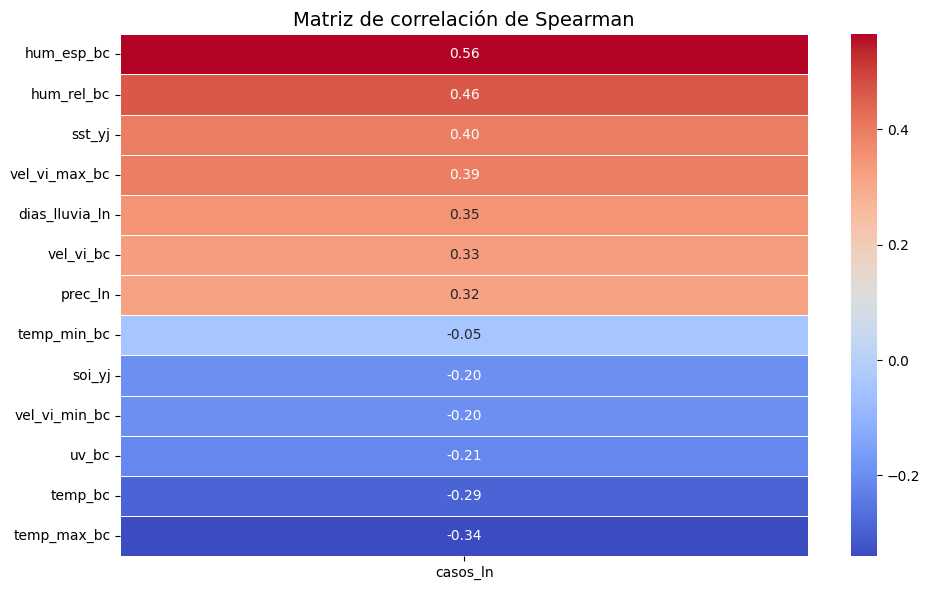

In [7]:
# Crear el mapa de calor
plt.figure(figsize=(10,6))
sns.heatmap(corr_spearman[['casos_ln']].sort_values(by='casos_ln', ascending=False)[1:], 
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Matriz de correlación de Spearman', fontsize=14)
plt.tight_layout()
#plt.savefig(f"{ubicacion_imagenes_janis}/10.heatmap_correlacion_spearman.png")
plt.show()

# Test VIF para eliminar variables con alta multicolinealidad

In [8]:
# Test VIF para casos_ln
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Seleccionar solo variables numéricas (sin fecha)
df_vif = df_procesados.select_dtypes(include=['float64', 'int64']).drop(columns=['año', 'semana_epi'])
# Calcular VIF
vif_data = pd.DataFrame()
vif_data["feature"] = df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(len(df_vif.columns))]
print(vif_data.sort_values(by='VIF', ascending=False))


           feature         VIF
4      temp_max_bc  108.544215
7       hum_rel_bc  101.968946
3          temp_bc   73.932615
6       hum_esp_bc   22.328332
5      temp_min_bc   10.324791
9    vel_vi_max_bc    9.680743
8        vel_vi_bc    6.791570
1          prec_ln    6.142949
2   dias_lluvia_ln    5.980194
13          sst_yj    2.461504
0         casos_ln    2.322640
10   vel_vi_min_bc    1.849046
12          soi_yj    1.501417
11           uv_bc    1.418005


In [9]:
# Test VIF para casos_ln
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Seleccionar solo variables numéricas (sin fecha)
df_vif2 = df_procesados.select_dtypes(include=['float64', 'int64']).drop(columns=['año', 'semana_epi', 'hum_rel_bc','temp_min_bc','soi_yj', 'vel_vi_min_bc', 'uv_bc', 'temp_bc', 'vel_vi_bc','dias_lluvia_ln'])
# Calcular VIF
vif_data = pd.DataFrame()
vif_data["feature"] = df_vif2.columns
vif_data["VIF"] = [variance_inflation_factor(df_vif2.values, i) for i in range(len(df_vif2.columns))]
print(vif_data.sort_values(by='VIF', ascending=False))

         feature       VIF
3     hum_esp_bc  3.689722
2    temp_max_bc  3.312038
4  vel_vi_max_bc  2.302727
1        prec_ln  2.271401
0       casos_ln  1.721958
5         sst_yj  1.603766


In [12]:
cols = ['fecha', 'año', 'semana_epi'] + [c for c in df_vif2.columns if c != 'casos_ln'] + ['casos_ln']
df_procesados_vif = df_procesados.reset_index()[cols]
df_procesados_vif.to_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\datos_procesados\datos_procesados_var_corr\datos_var_corr.xlsx", index=False)

OSError: Cannot save file into a non-existent directory: 'C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\datos_procesados\datos_procesados_var_corr'

# Definir Rezagos

In [10]:
lags_dict = {
    'prec_ln': 8,
    'temp_max_bc': 8,
    'hum_esp_bc': 8,
    'vel_vi_max_bc': 8,
    'sst_yj': 20  
}

In [13]:
df_lags = df_procesados_vif.copy()

for var, max_lag in lags_dict.items():
    for lag in range(1, max_lag + 1):
        df_lags[f'{var}_lag_{lag}'] = df_lags[var].shift(lag)

In [14]:
df_lags = df_lags.dropna().reset_index(drop=True)

In [15]:
from scipy.stats import spearmanr
import pandas as pd

resultados_sst = []

for lag in range(1, 21):
    col = f'sst_yj_lag_{lag}'
    
    coef, p = spearmanr(df_lags['casos_ln'], df_lags[col])
    
    resultados_sst.append({
        'variable': col,
        'correlacion': coef,
        'p_value': p
    })

df_sst_corr = pd.DataFrame(resultados_sst)
df_sst_corr['abs_corr'] = df_sst_corr['correlacion'].abs()
df_sst_corr = df_sst_corr.sort_values(by='abs_corr', ascending=False)

df_sst_corr.head(10)

,variable,correlacion,p_value,abs_corr
19,sst_yj_lag_20,0.477454,3.983102e-15,0.477454
18,sst_yj_lag_19,0.471742,9.299833e-15,0.471742
17,sst_yj_lag_18,0.459922,5.117295e-14,0.459922
16,sst_yj_lag_17,0.452212,1.502980e-13,0.452212
15,sst_yj_lag_16,0.450963,1.785085e-13,0.450963
14,sst_yj_lag_15,0.443676,4.802380e-13,0.443676
13,sst_yj_lag_14,0.441162,6.719757e-13,0.441162
12,sst_yj_lag_13,0.441098,6.777912e-13,0.441098
11,sst_yj_lag_12,0.436003,1.327634e-12,0.436003
10,sst_yj_lag_11,0.433476,1.845455e-12,0.433476


# Crear la base de datos para el modelo 1 que contienen las variables significativas con su respectivo rezago relevante de cada una

In [16]:
df_modelo_1 = df_procesados_vif.copy()

# Crear rezagos específicos
df_modelo_1['hum_esp_bc_lag_6'] = df_modelo_1['hum_esp_bc'].shift(6)
df_modelo_1['vel_vi_max_bc_lag_5'] = df_modelo_1['vel_vi_max_bc'].shift(5)
df_modelo_1['prec_ln_lag_8'] = df_modelo_1['prec_ln'].shift(8)
df_modelo_1['temp_max_bc_lag_7'] = df_modelo_1['temp_max_bc'].shift(7)
df_modelo_1['sst_yj_lag_20'] = df_modelo_1['sst_yj'].shift(20)

In [17]:
df_modelo_final_1 = df_modelo_1[[
    'fecha',
    'año',
    'semana_epi',
    'casos_ln',
    'hum_esp_bc_lag_6',
    'vel_vi_max_bc_lag_5',
    'prec_ln_lag_8',
    'temp_max_bc_lag_7',
    'sst_yj_lag_20'
]]

In [18]:
df_modelo_final_1 = df_modelo_final_1.dropna().reset_index(drop=True)

In [19]:
df_modelo_final_1.head()
df_modelo_final_1.shape

(241, 9)

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df_modelo_final_1.drop(columns=['fecha', 'año', 'semana_epi', 'casos_ln'])

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data

,Variable,VIF
0,hum_esp_bc_lag_6,2.454898
1,vel_vi_max_bc_lag_5,2.204971
2,prec_ln_lag_8,1.759622
3,temp_max_bc_lag_7,2.738654
4,sst_yj_lag_20,1.253367


In [44]:
# Guardar bd final para modelado
df_modelo_final_1.to_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\datos_modelos\datos_modelo_1_var_rezago_relevante.xlsx", index=False)

# Crear la base de datos para el modelo 2 que contienen las variables significativas con sus respectivos promedios de sus rezagos relevantes

In [21]:
df_modelo2 = df_procesados_vif.copy()

for lag in range(1, 21):
    df_modelo2[f'hum_esp_bc_lag_{lag}'] = df_modelo2['hum_esp_bc'].shift(lag)
    df_modelo2[f'vel_vi_max_bc_lag_{lag}'] = df_modelo2['vel_vi_max_bc'].shift(lag)
    df_modelo2[f'prec_ln_lag_{lag}'] = df_modelo2['prec_ln'].shift(lag)
    df_modelo2[f'temp_max_bc_lag_{lag}'] = df_modelo2['temp_max_bc'].shift(lag)
    df_modelo2[f'sst_yj_lag_{lag}'] = df_modelo2['sst_yj'].shift(lag)

C:\Users\usuario1\AppData\Local\Temp\ipykernel_19332\1627051266.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_modelo2[f'prec_ln_lag_{lag}'] = df_modelo2['prec_ln'].shift(lag)
C:\Users\usuario1\AppData\Local\Temp\ipykernel_19332\1627051266.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_modelo2[f'temp_max_bc_lag_{lag}'] = df_modelo2['temp_max_bc'].shift(lag)
C:\Users\usuario1\AppData\Local\Temp\ipykernel_19332\1627051266.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calli

In [22]:
# HUMEDAD (lags 4–8)
lags_hum = [4,5,6,7,8]
df_modelo2['hum_esp_bc_mean_lags_4_8'] = df_modelo2[
    [f'hum_esp_bc_lag_{i}' for i in lags_hum]
].mean(axis=1)

# VIENTO (lags 3–6)
lags_viento = [3,4,5,6]
df_modelo2['vel_vi_max_bc_mean_lags_3_6'] = df_modelo2[
    [f'vel_vi_max_bc_lag_{i}' for i in lags_viento]
].mean(axis=1)

# PRECIPITACIÓN (lags 5–8)
lags_prec = [5,6,7,8]
df_modelo2['prec_ln_mean_lags_5_8'] = df_modelo2[
    [f'prec_ln_lag_{i}' for i in lags_prec]
].mean(axis=1)

# TEMPERATURA (lags 5–8)
lags_temp = [5,6,7,8]
df_modelo2['temp_max_bc_mean_lags_5_8'] = df_modelo2[
    [f'temp_max_bc_lag_{i}' for i in lags_temp]
].mean(axis=1)

# SST (lags 16–20)
lags_sst = [16,17,18,19,20]
df_modelo2['sst_yj_mean_lags_16_20'] = df_modelo2[
    [f'sst_yj_lag_{i}' for i in lags_sst]
].mean(axis=1)

C:\Users\usuario1\AppData\Local\Temp\ipykernel_19332\2867842040.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_modelo2['hum_esp_bc_mean_lags_4_8'] = df_modelo2[
C:\Users\usuario1\AppData\Local\Temp\ipykernel_19332\2867842040.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_modelo2['vel_vi_max_bc_mean_lags_3_6'] = df_modelo2[
C:\Users\usuario1\AppData\Local\Temp\ipykernel_19332\2867842040.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whic

In [23]:
df_modelo_final_2 = df_modelo2[[
    'fecha',
    'año',
    'semana_epi',
    'casos_ln',
    'hum_esp_bc_mean_lags_4_8',
    'vel_vi_max_bc_mean_lags_3_6',
    'prec_ln_mean_lags_5_8',
    'temp_max_bc_mean_lags_5_8',
    'sst_yj_mean_lags_16_20'
]]

In [24]:
df_modelo_final_2 = df_modelo_final_2.dropna().reset_index(drop=True)

In [25]:
df_modelo_final_2.head()
df_modelo_final_2.shape

(245, 9)

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df_modelo_final_2.drop(columns=['fecha', 'año', 'semana_epi', 'casos_ln'])

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,Variable,VIF
0,hum_esp_bc_mean_lags_4_8,5.203490
1,vel_vi_max_bc_mean_lags_3_6,3.541897
2,prec_ln_mean_lags_5_8,3.230473
3,temp_max_bc_mean_lags_5_8,4.754608
4,sst_yj_mean_lags_16_20,1.679602


In [63]:
# Guardar bd final para modelado
df_modelo_final_2.to_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\datos_modelos\datos_modelo_2_var_prom_rezagos_relevantes.xlsx", index=False)